# Future Extreme Rainfall Changes

This notebook analyses how **maximum daily rainfall** (RX1day) is projected to change under climate change, and which road segments are most affected.

**Key steps:**
1. Load climate model ensemble data for extreme precipitation
2. Assess model agreement on the direction of change
3. Assign the ensemble median change (%) to each road segment
4. Visualise results across 4 scenarios (RCP 4.5 / 8.5 × near / far future)
5. Save results as ArcGIS layers

> **Data:** NetCDF files from a multi-model ensemble, with per-model change values and ensemble medians for the 20-year return period maximum daily precipitation (RX1day). Only grid cells where ≥5 of 8 models agree on the direction of change are shown.
>
> **Scenarios:**
> - **RCP 4.5** — moderate emissions pathway
> - **RCP 8.5** — high emissions pathway
> - **Period 1** — near future (2031–2060)
> - **Period 2** — far future (2071–2100)

## Step 1: Setup and Imports

In [1]:
import string
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from affine import Affine
from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio import features
from rasterio.features import geometry_mask
from shapely.geometry import mapping

warnings.simplefilter(action="ignore", category=FutureWarning)

### Helper functions

In [8]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")

### Define file paths

In [9]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
precip_path = data_path / "Climate Change Precipitation" / "results"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

for d in [figure_path, intermediate_results_path, arcgis_results, arcgis_gpkg]:
    d.mkdir(parents=True, exist_ok=True)

### Helper function

In [10]:
def max_raster_along_line(line, raster, transform):
    """Returns the maximum raster value intersecting a line geometry."""
    mask = geometry_mask(
        [mapping(line)],
        transform=transform,
        invert=True,
        out_shape=raster.shape
    )
    values = raster[mask]
    if np.all(np.isnan(values)):
        return np.nan
    return np.nanmax(values)

## Step 2: Load Data

In [11]:
# Load road network
roads_base = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")
print(f"Road segments loaded: {len(roads_base):,}")

# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_plot = world.loc[world.SOV_A3 == 'SRB']

# Clip to Serbia only (remove Kosovo roads)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))
serbia = country_plot.to_crs("EPSG:4326")

Road segments loaded: 2,023


## Step 3: Process All Scenarios

For each combination of RCP and time period, we:
1. Load the per-model change data and ensemble median
2. Classify model agreement (≥5 of 8 models must agree on direction)
3. Mask the ensemble median to areas with agreement
4. Assign the maximum change (%) to each road segment

In [12]:
results = {}

for rcp in ("45", "85"):
    results[rcp] = {}
    for period in ("1", "2"):
        rcp_text = "4.5" if rcp == "45" else "8.5"
        period_text = "2031-2060" if period == "1" else "2071-2100"
        print(f"\nProcessing RCP {rcp_text}, {period_text}...")

        # Load per-model data
        ds = xr.open_dataset(precip_path / f"rcp{rcp}_rx1d_change{period}.nc")
        ds = ds.rio.write_crs("EPSG:4326")
        ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

        # Load ensemble median
        ens = xr.open_dataset(precip_path / f"rcp{rcp}_rx1d_change{period}_ensmed.nc")
        ens = ens.rio.write_crs("EPSG:4326")
        ens = ens.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

        # Rename ensemble variables for consistency
        ens = ens.rename({
            "Change_ensmed_T20": "Change_T20",
            "Change_ensmed_T50": "Change_T50",
            "Change_ensmed_T100": "Change_T100",
            "Change_ensmed_T500": "Change_T500",
            "Change_ensmed_T1000": "Change_T1000",
        })

        # Use the 20-year return period
        data = ds["Change_T20"]
        ensemble = ens["Change_T20"]

        # Model agreement: count positive/negative models
        n_pos = (data > 0).sum(dim="model")
        n_neg = (data < 0).sum(dim="model")

        agreement = xr.zeros_like(n_pos)
        for thresh in [5, 6, 7, 8]:
            agreement = xr.where(n_pos == thresh, thresh - 4, agreement)
            agreement = xr.where(n_neg == thresh, -(thresh - 4), agreement)

        # Mask ensemble median to areas with agreement
        ensemble_masked = ensemble.where(agreement != 0)

        # Rasterize Serbia mask
        lon = ensemble.longitude.values
        lat = ensemble.latitude.values
        transform = Affine.translation(lon[0], lat[0]) * Affine.scale(lon[1] - lon[0], lat[1] - lat[0])

        serbia_mask = features.rasterize(
            [(geom, 1) for geom in serbia.geometry],
            out_shape=(len(lat), len(lon)),
            transform=transform, fill=0, dtype="uint8",
        )
        serbia_mask_xr = xr.DataArray(
            serbia_mask,
            coords={"latitude": lat, "longitude": lon},
            dims=("latitude", "longitude"),
        )
        ensemble_masked = ensemble_masked.where(serbia_mask_xr == 1)

        # Convert to percent
        ensemble_pct = ensemble_masked * 100
        raster_values = ensemble_pct.values

        # Assign to roads
        roads = roads_base.copy()
        if roads.crs != "EPSG:4326":
            roads = roads.to_crs("EPSG:4326")

        roads["max_rx1day_pct"] = roads.geometry.apply(
            lambda geom: max_raster_along_line(geom, raster_values, transform)
        )

        roads_with = roads[roads["max_rx1day_pct"].notna()]
        roads_without = roads[roads["max_rx1day_pct"].isna()]

        results[rcp][period] = {
            "roads_with_agreement": roads_with,
            "no_agreement": roads_without,
        }

        print(f"  Roads with signal: {len(roads_with):,}, no agreement: {len(roads_without):,}")
        if len(roads_with) > 0:
            print(f"  Change range: {roads_with['max_rx1day_pct'].min():.1f}% to {roads_with['max_rx1day_pct'].max():.1f}%")


Processing RCP 4.5, 2031-2060...
  Roads with signal: 1,658, no agreement: 365
  Change range: -4.6% to 12.5%

Processing RCP 4.5, 2071-2100...
  Roads with signal: 1,653, no agreement: 370
  Change range: -5.6% to 15.0%

Processing RCP 8.5, 2031-2060...
  Roads with signal: 1,702, no agreement: 321
  Change range: -4.9% to 18.1%

Processing RCP 8.5, 2071-2100...
  Roads with signal: 1,778, no agreement: 245
  Change range: -1.0% to 20.8%


## Step 4: Visualise — 2×2 Scenario Comparison

Each panel shows the projected change in maximum daily precipitation on roads. Blue = decrease, red = increase. Grey roads have no model agreement.

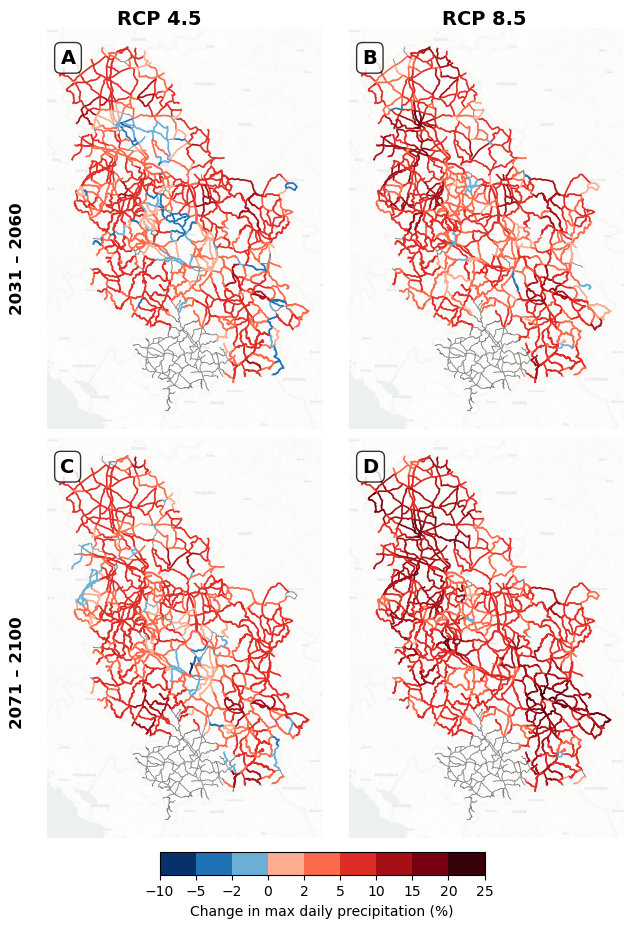

In [13]:
rcps = ["45", "85"]
periods = ["1", "2"]

fig, axes = plt.subplots(2, 2, figsize=(6.5, 9.2), sharex=True, sharey=True)
fig.subplots_adjust(left=0.06, right=0.98, top=0.98, bottom=0.10, wspace=0.02, hspace=0.02)

# Colour scheme: blue (decrease) → red (increase)
precip_bins = [-10, -5, -2, 0, 2, 5, 10, 15, 20, 25]
precip_colors = [
    "#08306b", "#2171b5", "#6baed6",  # decrease
    "#fcae91", "#fb6a4a", "#de2d26",  # increase
    "#a50f15", "#770111", "#360108",  # strong increase
]
cmap = ListedColormap(precip_colors)
norm = BoundaryNorm(precip_bins, cmap.N)

for row, period in enumerate(periods):
    for col, rcp in enumerate(rcps):
        ax = axes[row, col]

        gdf_with = results[rcp][period]["roads_with_agreement"].to_crs(3857)
        gdf_no = results[rcp][period]["no_agreement"].to_crs(3857)

        # Grey roads (no agreement)
        gdf_no.plot(ax=ax, color="grey", linewidth=0.6)

        # Coloured roads (with signal)
        gdf_with.plot(
            ax=ax, column="max_rx1day_pct",
            norm=norm, cmap=cmap, linewidth=1.2, legend=False,
        )

        cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
                       alpha=0.4, attribution=False)
        ax.set_axis_off()

# Row and column labels
rcps_title = ["4.5", "8.5"]
periods_title = ["2031 – 2060", "2071 – 2100"]

for col, rcp in enumerate(rcps_title):
    x = 0.25 if col == 0 else 0.75
    fig.text(x, 0.98, f"RCP {rcp}", ha="center", va="bottom",
             fontsize=14, fontweight="bold")

for row, period in enumerate(periods_title):
    y = 0.73 if row == 0 else 0.28
    fig.text(0.02, y, period, ha="left", va="center",
             fontsize=12, rotation=90, fontweight="bold")

# Panel labels (A, B, C, D)
axes_sorted = sorted(axes.flatten(),
                     key=lambda ax: (-ax.get_position().y0, ax.get_position().x0))
for i, ax in enumerate(axes_sorted):
    ax.text(0.05, 0.95, string.ascii_uppercase[i], transform=ax.transAxes,
            fontsize=14, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cax = fig.add_axes([0.25, 0.06, 0.5, 0.025])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Change in max daily precipitation (%)")
cbar.set_ticks(precip_bins)

for ax in axes.flat:
    ax.margins(0)

plt.savefig(figure_path / "change_in_Rx1d.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 5: Save Results as ArcGIS Layers

We save the **RCP 8.5, far future (2071–2100)** scenario as the primary output — the most severe projection.

In [14]:
# Use RCP 8.5, far future as the primary output
roads_output = results["85"]["2"].get("roads_with_agreement", pd.DataFrame()).copy()

if len(roads_output) > 0:
    # Classify into bins
    output_bins = [-10, -2, 0, 5, 10, 20, 25]
    output_labels = ["Decrease (>2%)", "Near zero", "Slight increase (0-5%)",
                     "Moderate increase (5-10%)", "Strong increase (10-20%)",
                     "Very strong increase (20%+)"]
    output_colors = ["#2171b5", "#d1e5f0", "#fcae91", "#fb6a4a", "#de2d26", "#67000d"]

    roads_output["precip_class"] = pd.cut(
        roads_output["max_rx1day_pct"],
        bins=output_bins, labels=output_labels, include_lowest=True,
    ).astype(str)
    roads_output["precip_class"] = roads_output["precip_class"].fillna("No data")

    save_lyrx_layer(
        gdf=roads_output,
        gpkg_path=arcgis_gpkg / "extreme_rainfall_change_roads.gpkg",
        lyrx_path=arcgis_results / "extreme_rainfall_change_roads.lyrx",
        layer_name="extreme_rainfall_change_roads",
        labels=output_labels,
        colors=output_colors,
        width_mapping={label: 1.2 for label in output_labels},
        field="precip_class",
        title="Change in Extreme Daily Rainfall (RCP 8.5, 2071–2100)",
    )

    print("\n✅ Done! Open 'extreme_rainfall_change_roads.lyrx' in ArcGIS Pro.")
else:
    print("No roads with model agreement found — check input data.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\extreme_rainfall_change_roads.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\extreme_rainfall_change_roads.lyrx

✅ Done! Open 'extreme_rainfall_change_roads.lyrx' in ArcGIS Pro.
